In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

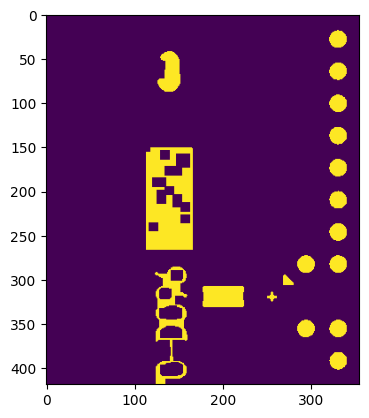

In [33]:
img = cv2.imread(r'd:\\ImageMatrix\\200128837_96_0(0)_NG.jpg', cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
morphed = cv2.dilate(binary, kernel, iterations=2)
morphed = cv2.erode(morphed, kernel, iterations=2)
plt.imshow(morphed)

320 383 20 20
320 346 20 20
284 346 20 20
250 314 11 12
177 308 47 24
268 295 12 12
123 286 37 133
320 273 20 20
284 273 20 20
320 237 20 20
320 200 20 20
320 164 20 20
113 151 53 116
320 128 20 20
320 91 20 20
320 55 20 20
126 42 26 46
320 18 20 20
325 0 10 2
Saved ROI: x=113, y=151, w=53, h=116


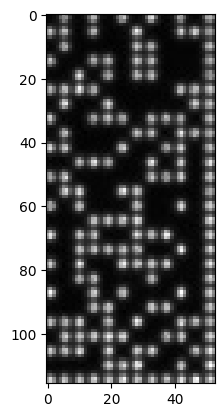

In [40]:
# 가장 큰 contour 저장용
max_area = 0
best_rect = None

contours, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    print(x,y,w,h)
    area = w * h
    aspect = w / float(h)

    # 가장 큰 영역 찾기
    if area > max_area:
        max_area = area
        best_rect = (x, y, w, h)

# 가장 큰 ROI 저장
if best_rect:
    x, y, w, h = best_rect
    roi = img[151:267, 113:166]
    plt.imshow(roi, cmap='gray')
    print(f"Saved ROI: x={x}, y={y}, w={w}, h={h}")
else:
    print("No valid Datamatrix ROI found.")

Bounding box (center-closest): x=176, y=192, w=4, h=5


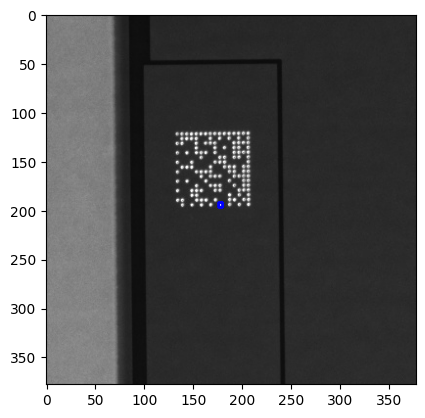